In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

# Leer tu dataset (emociones.csv limpio con ; como separador)
df = pd.read_csv("../../../docs/poblaciones/HMM csv/emocionesGenerales.csv", sep=";")

# Mapa de emociones a números
estado_map = {"E": 0, "Ne": 1, "N": 2, "Ni": 3, "I": 4}
estado_inv_map = {v: k for k, v in estado_map.items()}

# Codificar
df_cod = df.map(estado_map.get)

# Crear matriz 5x5
trans_matrix = np.zeros((5, 5), dtype=int)

# Llenar la matriz con datos reales
for _, row in df_cod.iterrows():
    secuencia = row.tolist()
    for i in range(len(secuencia) - 1):
        origen = secuencia[i]
        destino = secuencia[i + 1]
        if origen is not None and destino is not None:
            trans_matrix[origen, destino] += 1

# Normalizar a probabilidades y corregir posibles errores
trans_probs = np.zeros_like(trans_matrix, dtype=float)

for i in range(5):
    row_sum = trans_matrix[i].sum()
    if row_sum > 0:
        trans_probs[i] = trans_matrix[i] / row_sum
        # Asegurar que suma 1 exactamente (ajuste por errores de redondeo)
        diff = 1.0 - trans_probs[i].sum()
        max_idx = np.argmax(trans_probs[i])
        trans_probs[i][max_idx] += diff  # Corrige en la entrada de mayor peso
    else:
        # Si la fila está vacía (sin transiciones desde ese estado), asigna prob uniforme
        trans_probs[i] = np.ones(5) / 5

# Verificar que todas las filas suman 1 (opcional)
row_sums = trans_probs.sum(axis=1)


# Mostrar matriz
df_trans = pd.DataFrame(
    trans_probs,
    index=["E", "Ne", "N", "Ni", "I"],
    columns=["E", "Ne", "N", "Ni", "I"]
)

display(df_trans.round(3))


,E,Ne,N,Ni,I
E,0.207,0.000,0.207,0.517,0.069
Ne,0.000,0.250,0.500,0.250,0.000
N,0.107,0.000,0.339,0.107,0.446
Ni,0.298,0.035,0.175,0.368,0.123
I,0.000,0.000,0.633,0.267,0.100


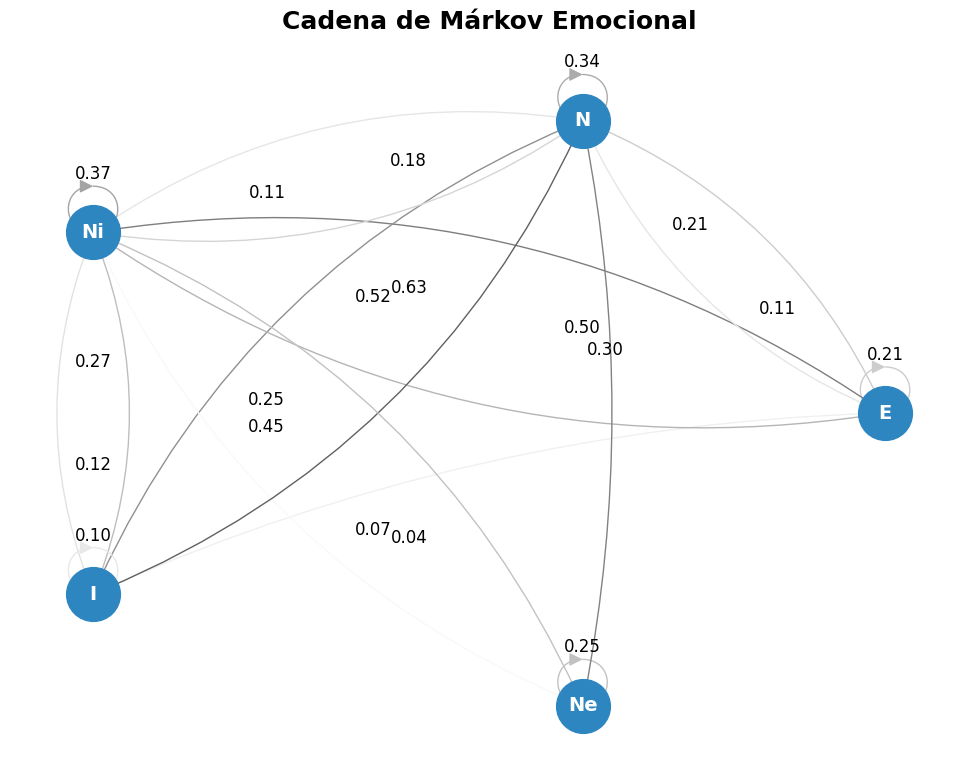

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Estados
estados = ['E', 'Ne', 'N', 'Ni', 'I']

# Crear grafo dirigido
G = nx.DiGraph()

for i, origen in enumerate(estados):
    for j, destino in enumerate(estados):
        peso = trans_probs[i][j]
        if peso > 0.01:
            G.add_edge(origen, destino, weight=peso)

# 🎯 Aumentar tamaño de figura
plt.figure(figsize=(10, 8))

pos = nx.circular_layout(G)

nx.draw_networkx_nodes(G, pos, node_color='#2E86C1', node_size=1500)
nx.draw_networkx_labels(G, pos, font_color='white', font_size=14, font_weight='bold')

for u, v, data in G.edges(data=True):
    peso = data['weight']
    color = str(1.01 - peso)
    rad = 0.35 if u == v else (0.2 if (v, u) in G.edges else 0.1)
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v)],
        edge_color=color,
        connectionstyle=f'arc3,rad={rad}',
        arrows=True,
        arrowsize=20
    )

# Dibujar etiquetas con transparencia
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=12,
    rotate=False,
    label_pos=0.65,
    bbox=dict(boxstyle='round,pad=0.1', fc='none', ec='none')
)

plt.title("Cadena de Márkov Emocional", fontsize=18, fontweight='bold')
plt.axis('off')
plt.tight_layout(pad=1.5)